# ICP on the two Station 5 systems

* System 1: `env = ~ Station5_mp_87`
* System 2: `env = ~ Station5_mp_85 + Station5_mp_94`

Hiding U = dropping the column from the formula.

In [1]:
library(tramicp)

sys1 <- read.csv("station5_system1.csv")
sys2 <- read.csv("station5_system2.csv")

## Graphs: DAG, ADMG

In [2]:
.libPaths(c("~/R/library", .libPaths()))
library(glip, lib.loc = "~/R/library")
library(igraph, lib.loc = "~/R/library")

Loading required package: comets

Registered S3 methods overwritten by 'comets':
  method               from   
  residuals.qrf        tramicp
  residuals.survforest tramicp

Loading required package: pcalg


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




In [3]:
library(glip)

gr <- as.matrix(read.csv("causalassembly-adjacency-matrix.csv")[, -1])
rownames(gr) <- colnames(gr)

system1 <- paste0("Station5_mp_", c(87, 82, 89, 83, 84, 86))
system2 <- paste0("Station5_mp_", c(85, 94, 95, 90, 91, 97, 93, 92))

g1 <- gr[system1, system1]
g2 <- gr[system2, system2]


Attaching package: ‘generics’


The following objects are masked from ‘package:igraph’:

    components, union


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:igraph’:

    normalize, path


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘graph’


The following objects are masked from ‘package:igraph’:

    degree, edg

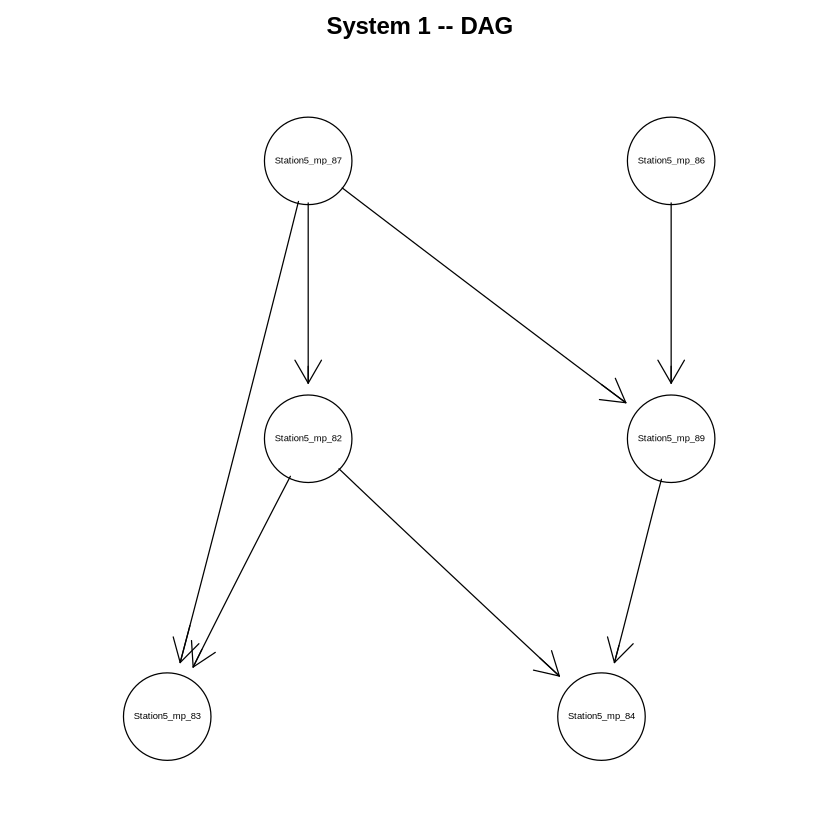

In [4]:
plot(as(g1, "graphNEL"), main = "System 1 -- DAG")

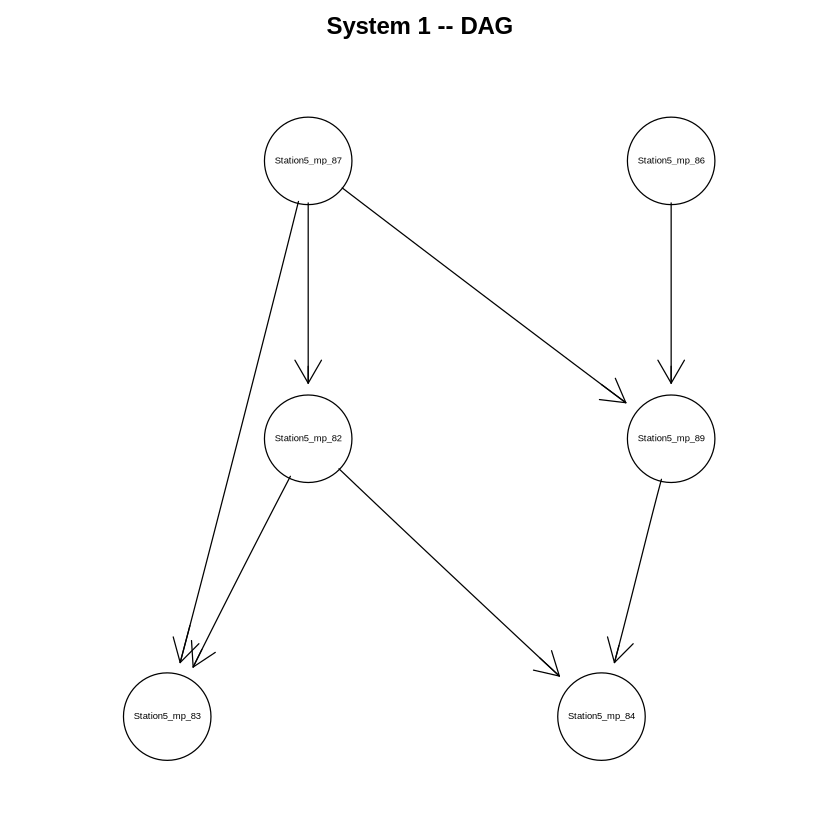

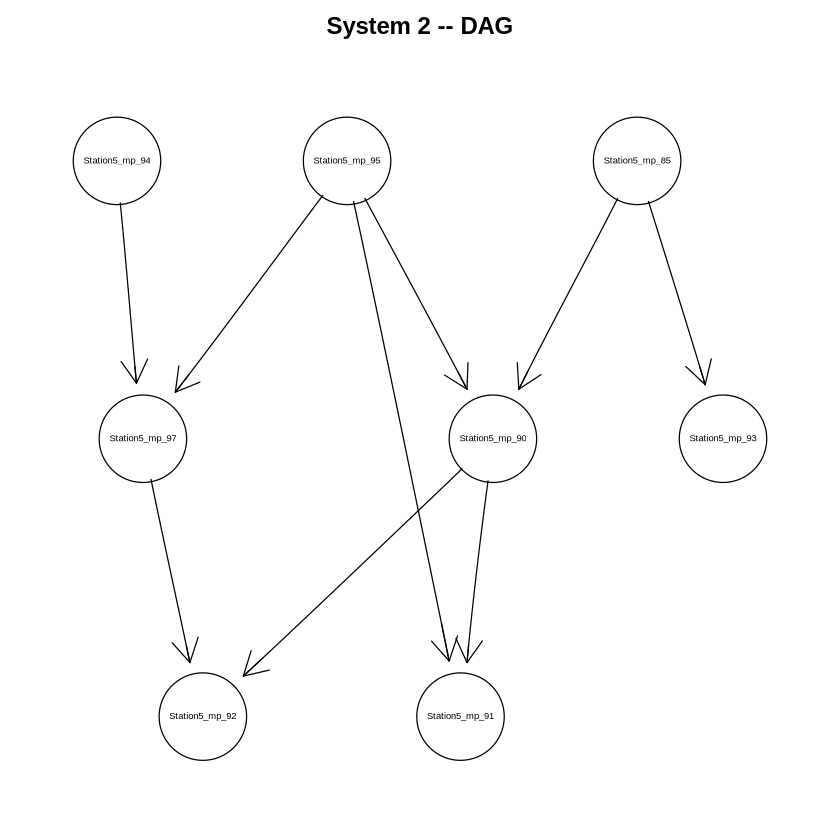

In [5]:
# DAGs
plot(as(g1, "graphNEL"), main = "System 1 -- DAG")
plot(as(g2, "graphNEL"), main = "System 2 -- DAG")

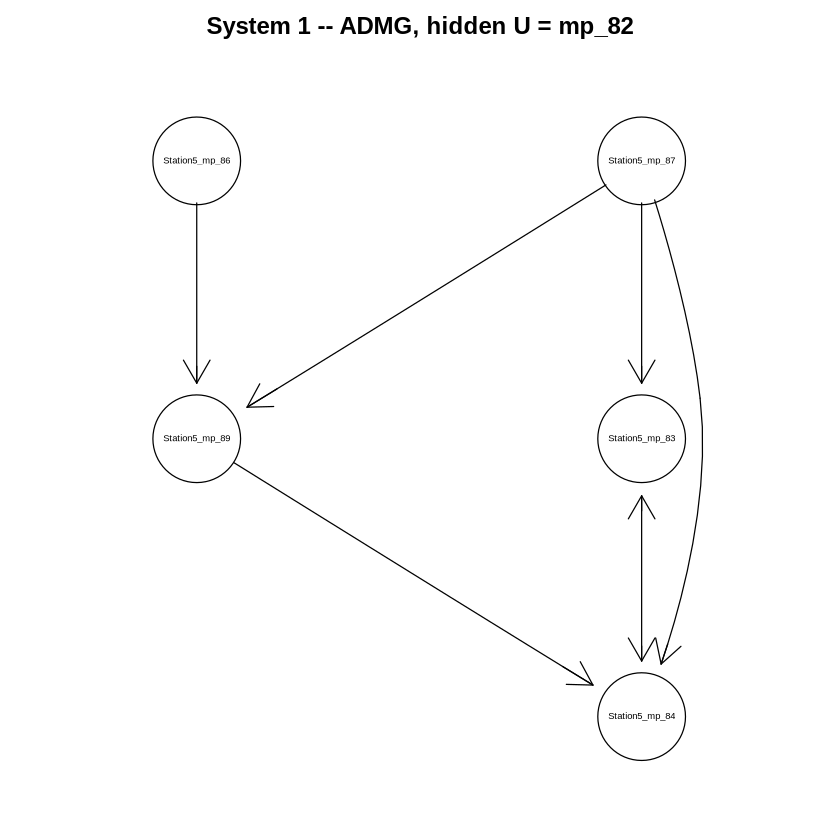

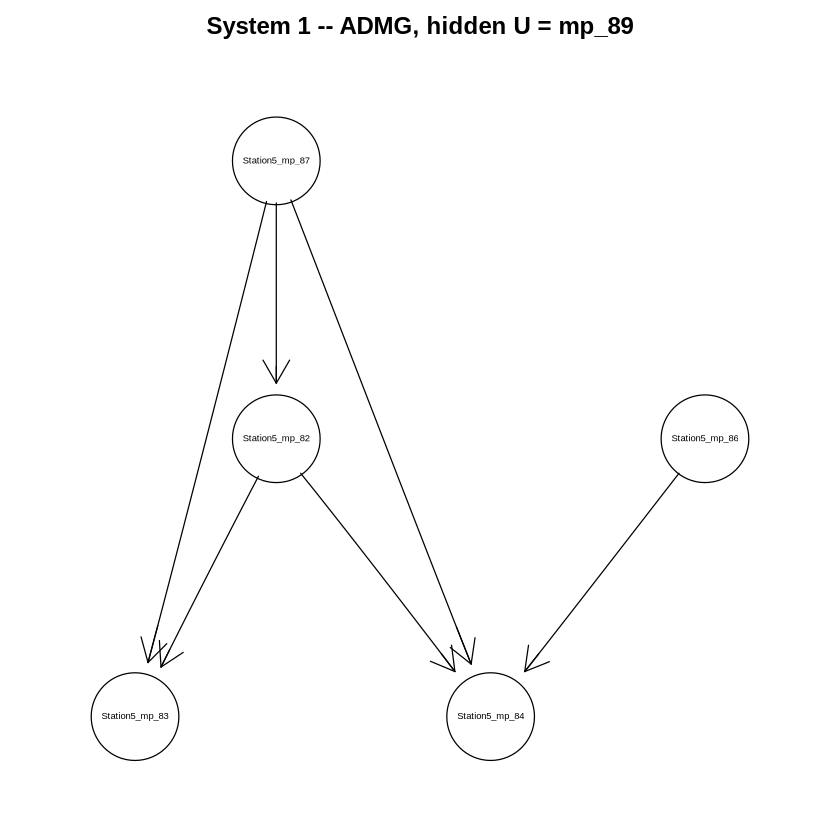

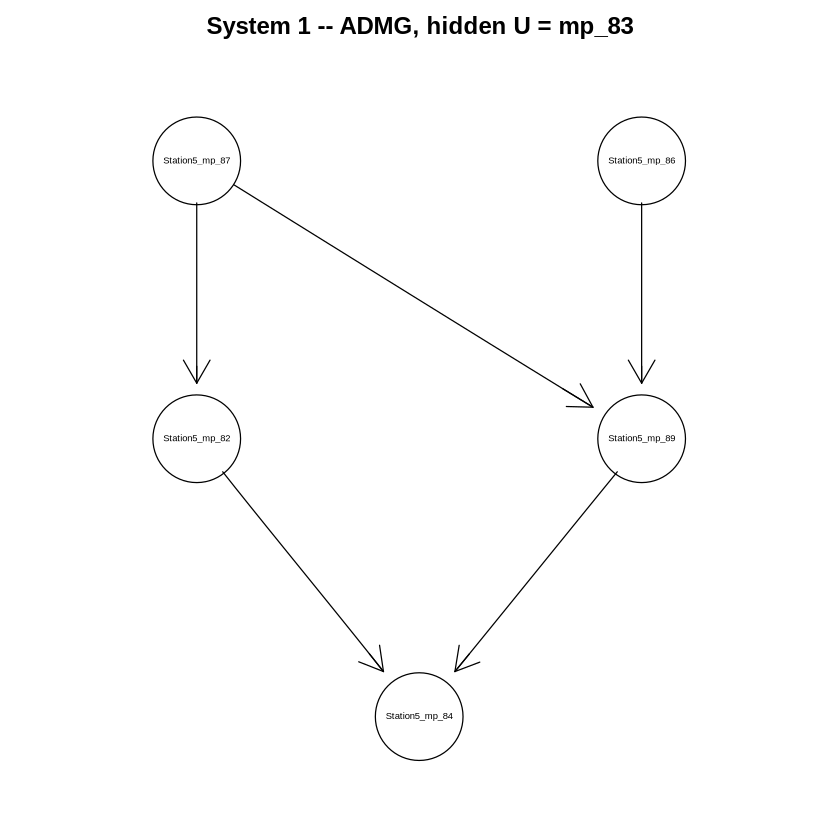

In [6]:
# System 1 ADMGs: one per hidden U
for (u in paste0("Station5_mp_", c(82, 89, 83))) {
  marg <- glip:::marginalize_dag_to_admg(g1, setdiff(system1, u))
  plot(as(unclass(marg$M1) + unclass(marg$M2), "graphNEL"),
       main = paste("System 1 -- ADMG, hidden U =", sub("Station5_", "", u)))
}

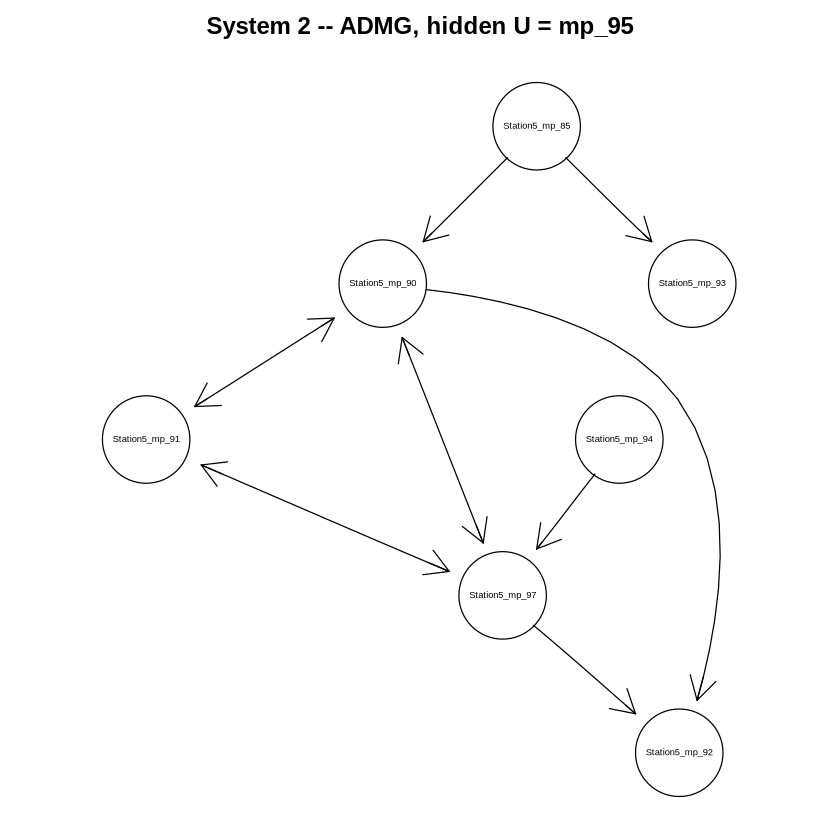

In [7]:
# System 2 ADMG: hidden U = 95 (expect mutual arrows among 90, 91, 97)
marg <- glip:::marginalize_dag_to_admg(g2, setdiff(system2, "Station5_mp_95"))
plot(as(unclass(marg$M1) + unclass(marg$M2), "graphNEL"),
     main = "System 2 -- ADMG, hidden U = mp_95")

## System 1: Y = 84, X = 82, 89, 83, E = 87

True parents of 84: 82 and 89.

In [8]:
sys1 <- as.data.frame(scale(sys1))

In [8]:
# baseline: all predictors observed
fit <- lmICP(Station5_mp_84 ~ Station5_mp_82 + Station5_mp_89 + Station5_mp_83 + Station5_mp_86,
             data = sys1, env = ~ Station5_mp_87, verbose = FALSE)
fit
pvalues(fit, which = "all")


 Model-based Invariant Causal Prediction

Call: lmICP(formula = Station5_mp_84 ~ Station5_mp_82 + Station5_mp_89 + 
    Station5_mp_83 + Station5_mp_86, data = sys1, env = ~Station5_mp_87, 
    verbose = FALSE)

 Invariance test: gcm.test 

 Predictor p-values:
Station5_mp_82 Station5_mp_89 Station5_mp_83 Station5_mp_86 
         0.000          0.724          0.877          0.877 

 Set of plausible causal predictors: Station5_mp_82 

$predictor_pvals
Station5_mp_82 Station5_mp_89 Station5_mp_83 Station5_mp_86 
   0.000302318    0.724466913    0.876573341    0.876573341 

$set_pvals
                                                      Empty 
                                              1.629655e-103 
                                             Station5_mp_82 
                                               4.010308e-15 
                                             Station5_mp_89 
                                               1.606154e-21 
                                             Station5_mp_83 
                                               3.023180e-04 
                                             Station5_mp_86 
                                              1.178122e-132 
                              Station5_mp_82+Station5_mp_89 
                                               8.765733e-01 
                              Station5_mp_82+Station5_mp_83 
                                               2.351790e-01 
                              Station5_mp_82+Station5_mp_86 
                                               1.038582e-20 
                              Station5_mp_89+Station5_mp_83 
                                               2.095075e-05 
                              Station5_mp_89+Station5_mp_86 
                                               9.937981e-23 
                              Station5_mp_83+Station5_mp_86 
                                               8.690844e-06 
               Station5_mp_82+Station5_mp_89+Station5_mp_83 
                                               6.366782e-01 
               Station5_mp_82+Station5_mp_89+Station5_mp_86 
                                               5.919752e-01 
               Station5_mp_82+Station5_mp_83+Station5_mp_86 
                                               7.244669e-01 
               Station5_mp_89+Station5_mp_83+Station5_mp_86 
                                               2.844416e-04 
Station5_mp_82+Station5_mp_89+Station5_mp_83+Station5_mp_86 
                                               6.606661e-01

In [9]:
# same with rangerICP
fit <- rangerICP(Station5_mp_84 ~ Station5_mp_82 + Station5_mp_89 + Station5_mp_83 + Station5_mp_86,
                 data = sys1, env = ~ Station5_mp_87, verbose = FALSE)
fit
pvalues(fit, which = "all")


 Model-based Invariant Causal Prediction

Call: rangerICP(formula = Station5_mp_84 ~ Station5_mp_82 + Station5_mp_89 + 
    Station5_mp_83 + Station5_mp_86, data = sys1, env = ~Station5_mp_87, 
    verbose = FALSE)

 Invariance test: gcm.test 

 Predictor p-values:
Station5_mp_82 Station5_mp_89 Station5_mp_83 Station5_mp_86 
         0.000          0.320          0.844          0.844 

 Set of plausible causal predictors: Station5_mp_82 

$predictor_pvals
Station5_mp_82 Station5_mp_89 Station5_mp_83 Station5_mp_86 
  0.0002141151   0.3201808041   0.8443901556   0.8443901556 

$set_pvals
                                                      Empty 
                                              1.629655e-103 
                                             Station5_mp_82 
                                               3.429896e-16 
                                             Station5_mp_89 
                                               9.946985e-28 
                                             Station5_mp_83 
                                               2.141151e-04 
                                             Station5_mp_86 
                                              7.195229e-182 
                              Station5_mp_82+Station5_mp_89 
                                               8.443902e-01 
                              Station5_mp_82+Station5_mp_83 
                                               3.201808e-01 
                              Station5_mp_82+Station5_mp_86 
                                               9.383690e-25 
                              Station5_mp_89+Station5_mp_83 
                                               4.697710e-06 
                              Station5_mp_89+Station5_mp_86 
                                               2.192529e-31 
                              Station5_mp_83+Station5_mp_86 
                                               3.900128e-07 
               Station5_mp_82+Station5_mp_89+Station5_mp_83 
                                               5.613973e-01 
               Station5_mp_82+Station5_mp_89+Station5_mp_86 
                                               7.005566e-01 
               Station5_mp_82+Station5_mp_83+Station5_mp_86 
                                               2.991765e-01 
               Station5_mp_89+Station5_mp_83+Station5_mp_86 
                                               1.086827e-05 
Station5_mp_82+Station5_mp_89+Station5_mp_83+Station5_mp_86 
                                               6.490763e-01

In [9]:
# hide U = 82, lmICP
fit <- lmICP(Station5_mp_84 ~ Station5_mp_89 + Station5_mp_83 + Station5_mp_86,
             data = sys1, env = ~ Station5_mp_87, verbose = FALSE)
fit
pvalues(fit, which = "all")


 Model-based Invariant Causal Prediction

Call: lmICP(formula = Station5_mp_84 ~ Station5_mp_89 + Station5_mp_83 + 
    Station5_mp_86, data = sys1, env = ~Station5_mp_87, verbose = FALSE)

 Invariance test: gcm.test 

 Predictor p-values:
Station5_mp_89 Station5_mp_83 Station5_mp_86 
             1              1              1 

 Set of plausible causal predictors: Empty 

$predictor_pvals
Station5_mp_89 Station5_mp_83 Station5_mp_86 
             1              1              1 

$set_pvals
                                       Empty 
                               1.629655e-103 
                              Station5_mp_89 
                                1.751010e-21 
                              Station5_mp_83 
                                2.892346e-04 
                              Station5_mp_86 
                               3.751144e-132 
               Station5_mp_89+Station5_mp_83 
                                2.555712e-05 
               Station5_mp_89+Station5_mp_86 
                                1.892286e-23 
               Station5_mp_83+Station5_mp_86 
                                1.101647e-05 
Station5_mp_89+Station5_mp_83+Station5_mp_86 
                                2.690042e-04

In [10]:
# hide U = 82, rangerICP
fit <- rangerICP(Station5_mp_84 ~ Station5_mp_89 + Station5_mp_83 + Station5_mp_86,
                 data = sys1, env = ~ Station5_mp_87, verbose = FALSE)
fit
pvalues(fit, which = "all")


 Model-based Invariant Causal Prediction

Call: rangerICP(formula = Station5_mp_84 ~ Station5_mp_89 + Station5_mp_83 + 
    Station5_mp_86, data = sys1, env = ~Station5_mp_87, verbose = FALSE)

 Invariance test: gcm.test 

 Predictor p-values:
Station5_mp_89 Station5_mp_83 Station5_mp_86 
             1              1              1 

 Set of plausible causal predictors: Empty 

$predictor_pvals
Station5_mp_89 Station5_mp_83 Station5_mp_86 
             1              1              1 

$set_pvals
                                       Empty 
                               1.629655e-103 
                              Station5_mp_89 
                                1.172570e-27 
                              Station5_mp_83 
                                1.769242e-04 
                              Station5_mp_86 
                               2.201934e-181 
               Station5_mp_89+Station5_mp_83 
                                1.479508e-06 
               Station5_mp_89+Station5_mp_86 
                                6.240249e-31 
               Station5_mp_83+Station5_mp_86 
                                7.779835e-07 
Station5_mp_89+Station5_mp_83+Station5_mp_86 
                                1.133151e-05

In [11]:
# hide U = 89, lmICP
fit <- lmICP(Station5_mp_84 ~ Station5_mp_82 + Station5_mp_83 + Station5_mp_86,
             data = sys1, env = ~ Station5_mp_87, verbose = FALSE)
fit
pvalues(fit, which = "all")


 Model-based Invariant Causal Prediction

Call: lmICP(formula = Station5_mp_84 ~ Station5_mp_82 + Station5_mp_83 + 
    Station5_mp_86, data = sys1, env = ~Station5_mp_87, verbose = FALSE)

 Invariance test: gcm.test 

 Predictor p-values:
Station5_mp_82 Station5_mp_83 Station5_mp_86 
         0.000          0.000          0.287 

 Set of plausible causal predictors: Station5_mp_82 Station5_mp_83 

$predictor_pvals
Station5_mp_82 Station5_mp_83 Station5_mp_86 
  2.841934e-04   4.844301e-15   2.869600e-01 

$set_pvals
                                       Empty 
                               1.629655e-103 
                              Station5_mp_82 
                                4.844301e-15 
                              Station5_mp_83 
                                2.841934e-04 
                              Station5_mp_86 
                               9.032025e-134 
               Station5_mp_82+Station5_mp_83 
                                2.869600e-01 
               Station5_mp_82+Station5_mp_86 
                                3.586477e-21 
               Station5_mp_83+Station5_mp_86 
                                5.667489e-06 
Station5_mp_82+Station5_mp_83+Station5_mp_86 
                                7.171753e-01

In [12]:
# hide U = 89, rangerICP
fit <- rangerICP(Station5_mp_84 ~ Station5_mp_82 + Station5_mp_83 + Station5_mp_86,
             data = sys1, env = ~ Station5_mp_87, verbose = FALSE)
fit
pvalues(fit, which = "all")


 Model-based Invariant Causal Prediction

Call: rangerICP(formula = Station5_mp_84 ~ Station5_mp_82 + Station5_mp_83 + 
    Station5_mp_86, data = sys1, env = ~Station5_mp_87, verbose = FALSE)

 Invariance test: gcm.test 

 Predictor p-values:
Station5_mp_82 Station5_mp_83 Station5_mp_86 
         0.000          0.000          0.353 

 Set of plausible causal predictors: Station5_mp_82 Station5_mp_83 

$predictor_pvals
Station5_mp_82 Station5_mp_83 Station5_mp_86 
  2.062671e-04   3.519684e-16   3.530093e-01 

$set_pvals
                                       Empty 
                               1.629655e-103 
                              Station5_mp_82 
                                3.519684e-16 
                              Station5_mp_83 
                                2.062671e-04 
                              Station5_mp_86 
                               1.507418e-181 
               Station5_mp_82+Station5_mp_83 
                                3.530093e-01 
               Station5_mp_82+Station5_mp_86 
                                6.876785e-25 
               Station5_mp_83+Station5_mp_86 
                                1.282213e-06 
Station5_mp_82+Station5_mp_83+Station5_mp_86 
                                4.480261e-01

In [13]:
# hide U = 83, lmICP
fit <- lmICP(Station5_mp_84 ~ Station5_mp_82 + Station5_mp_89 + Station5_mp_86,
             data = sys1, env = ~ Station5_mp_87, verbose = FALSE)
fit
pvalues(fit, which = "all")


 Model-based Invariant Causal Prediction

Call: lmICP(formula = Station5_mp_84 ~ Station5_mp_82 + Station5_mp_89 + 
    Station5_mp_86, data = sys1, env = ~Station5_mp_87, verbose = FALSE)

 Invariance test: gcm.test 

 Predictor p-values:
Station5_mp_82 Station5_mp_89 Station5_mp_86 
         0.000          0.000          0.915 

 Set of plausible causal predictors: Station5_mp_82 Station5_mp_89 

$predictor_pvals
Station5_mp_82 Station5_mp_89 Station5_mp_86 
  1.668072e-21   3.669690e-15   9.145359e-01 

$set_pvals
                                       Empty 
                               1.629655e-103 
                              Station5_mp_82 
                                3.669690e-15 
                              Station5_mp_89 
                                1.668072e-21 
                              Station5_mp_86 
                               2.449347e-131 
               Station5_mp_82+Station5_mp_89 
                                9.145359e-01 
               Station5_mp_82+Station5_mp_86 
                                5.084416e-21 
               Station5_mp_89+Station5_mp_86 
                                1.765649e-23 
Station5_mp_82+Station5_mp_89+Station5_mp_86 
                                5.903503e-01

In [14]:
# hide U = 83, rangerICP
fit <- rangerICP(Station5_mp_84 ~ Station5_mp_82 + Station5_mp_89 + Station5_mp_86,
             data = sys1, env = ~ Station5_mp_87, verbose = FALSE)
fit
pvalues(fit, which = "all")


 Model-based Invariant Causal Prediction

Call: rangerICP(formula = Station5_mp_84 ~ Station5_mp_82 + Station5_mp_89 + 
    Station5_mp_86, data = sys1, env = ~Station5_mp_87, verbose = FALSE)

 Invariance test: gcm.test 

 Predictor p-values:
Station5_mp_82 Station5_mp_89 Station5_mp_86 
         0.000          0.000          0.871 

 Set of plausible causal predictors: Station5_mp_82 Station5_mp_89 

$predictor_pvals
Station5_mp_82 Station5_mp_89 Station5_mp_86 
  1.072188e-27   3.636935e-16   8.712963e-01 

$set_pvals
                                       Empty 
                               1.629655e-103 
                              Station5_mp_82 
                                3.636935e-16 
                              Station5_mp_89 
                                1.072188e-27 
                              Station5_mp_86 
                               4.836260e-181 
               Station5_mp_82+Station5_mp_89 
                                8.712963e-01 
               Station5_mp_82+Station5_mp_86 
                                7.974974e-25 
               Station5_mp_89+Station5_mp_86 
                                2.500331e-31 
Station5_mp_82+Station5_mp_89+Station5_mp_86 
                                6.767439e-01

## System 2: Y = 92, X = 90, 97, 91, 93, E = 85 and 94, U = 95

True parents of 92: 90 and 97. Hiding 95 confounds 90/91/97 among each other,
but not with Y — ICP should still recover {90, 97}.

In [15]:
sys2 <- as.data.frame(scale(sys2))

In [16]:
# baseline 
fit <- lmICP(Station5_mp_92 ~ Station5_mp_90 + Station5_mp_97 + Station5_mp_91 + Station5_mp_93 + Station5_mp_95,
             data = sys2, env = ~ Station5_mp_85 + Station5_mp_94, verbose = FALSE)
fit
pvalues(fit, which = "all")


 Model-based Invariant Causal Prediction

Call: lmICP(formula = Station5_mp_92 ~ Station5_mp_90 + Station5_mp_97 + 
    Station5_mp_91 + Station5_mp_93 + Station5_mp_95, data = sys2, 
    env = ~Station5_mp_85 + Station5_mp_94, verbose = FALSE)

 Invariance test: gcm.test 

 Predictor p-values:
Station5_mp_90 Station5_mp_97 Station5_mp_91 Station5_mp_93 Station5_mp_95 
         0.638          0.000          0.967          0.967          0.952 

 Set of plausible causal predictors: Station5_mp_97 

$predictor_pvals
Station5_mp_90 Station5_mp_97 Station5_mp_91 Station5_mp_93 Station5_mp_95 
  6.383476e-01  6.300241e-195   9.665468e-01   9.665468e-01   9.522790e-01 

$set_pvals
                                                                     Empty 
                                                             5.513872e-226 
                                                            Station5_mp_90 
                                                             8.170845e-209 
                                                            Station5_mp_97 
                                                              4.809338e-02 
                                                            Station5_mp_91 
                                                             3.154225e-205 
                                                            Station5_mp_93 
                                                             1.504639e-224 
                                                            Station5_mp_95 
                                                             6.300241e-195 
                                             Station5_mp_90+Station5_mp_97 
                                                              9.522790e-01 
                                             Station5_mp_90+Station5_mp_91 
                                                             1.478516e-216 
                                             Station5_mp_90+Station5_mp_93 
                                                             3.882701e-222 
                                             Station5_mp_90+Station5_mp_95 
                                                             7.947711e-215 
                                             Station5_mp_97+Station5_mp_91 
                                                              1.133390e-01 
                                             Station5_mp_97+Station5_mp_93 
                                                              2.148483e-02 
                                             Station5_mp_97+Station5_mp_95 
                                                              1.993282e-01 
                                             Station5_mp_91+Station5_mp_93 
                                                             4.909637e-219 
                                             Station5_mp_91+Station5_mp_95 
                                                             3.944746e-216 
                                             Station5_mp_93+Station5_mp_95 
                                                             2.467222e-223 
                              Station5_mp_90+Station5_mp_97+Station5_mp_91 
                                                              9.361290e-01 
                              Station5_mp_90+Station5_mp_97+Station5_mp_93 
                                                              7.592036e-01 
                              Station5_mp_90+Station5_mp_97+Station5_mp_95 
                                                              9.665468e-01 
                              Station5_mp_90+Station5_mp_91+Station5_mp_93 
                                                             2.453633e-223 
                              Station5_mp_90+Station5_mp_91+Station5_mp_95 
                                                             1.054256e-218 
                              Station5_mp_90+Station5_mp_93+Station5_mp_95 
                                                             7.412677e-223 
                              Station5_mp_97+Station5_mp_91+Station5_mp_93 
                                                              9.390414e-02 
                              Station5_mp_97+Station5_mp_91+Station5_mp_95 
                                                              6.161781e-01 
                              Station5_mp_97+Station5_mp_93+Station5_mp_95 
                                                              3.667486e-01 
                   

In [17]:
# same with ranger 
fit <- rangerICP(Station5_mp_92 ~ Station5_mp_90 + Station5_mp_97 + Station5_mp_91 + Station5_mp_93 + Station5_mp_95,
             data = sys2, env = ~ Station5_mp_85 + Station5_mp_94, verbose = FALSE)
fit
pvalues(fit, which = "all")


 Model-based Invariant Causal Prediction

Call: rangerICP(formula = Station5_mp_92 ~ Station5_mp_90 + Station5_mp_97 + 
    Station5_mp_91 + Station5_mp_93 + Station5_mp_95, data = sys2, 
    env = ~Station5_mp_85 + Station5_mp_94, verbose = FALSE)

 Invariance test: gcm.test 

 Predictor p-values:
Station5_mp_90 Station5_mp_97 Station5_mp_91 Station5_mp_93 Station5_mp_95 
         0.438          0.000          0.753          0.752          0.752 

 Set of plausible causal predictors: Station5_mp_97 

$predictor_pvals
Station5_mp_90 Station5_mp_97 Station5_mp_91 Station5_mp_93 Station5_mp_95 
  4.379228e-01  5.513872e-226   7.526615e-01   7.521708e-01   7.521708e-01 

$set_pvals
                                                                     Empty 
                                                             5.513872e-226 
                                                            Station5_mp_90 
                                                             5.370884e-241 
                                                            Station5_mp_97 
                                                              3.607062e-02 
                                                            Station5_mp_91 
                                                             1.577611e-251 
                                                            Station5_mp_93 
                                                             7.848773e-230 
                                                            Station5_mp_95 
                                                             5.578399e-273 
                                             Station5_mp_90+Station5_mp_97 
                                                              7.521708e-01 
                                             Station5_mp_90+Station5_mp_91 
                                                             3.336703e-244 
                                             Station5_mp_90+Station5_mp_93 
                                                             1.795640e-238 
                                             Station5_mp_90+Station5_mp_95 
                                                             1.213723e-247 
                                             Station5_mp_97+Station5_mp_91 
                                                              6.742514e-02 
                                             Station5_mp_97+Station5_mp_93 
                                                              2.726086e-02 
                                             Station5_mp_97+Station5_mp_95 
                                                              1.123125e-01 
                                             Station5_mp_91+Station5_mp_93 
                                                             1.653943e-235 
                                             Station5_mp_91+Station5_mp_95 
                                                             4.500392e-246 
                                             Station5_mp_93+Station5_mp_95 
                                                             6.206096e-244 
                              Station5_mp_90+Station5_mp_97+Station5_mp_91 
                                                              2.420572e-01 
                              Station5_mp_90+Station5_mp_97+Station5_mp_93 
                                                              4.763859e-01 
                              Station5_mp_90+Station5_mp_97+Station5_mp_95 
                                                              4.995264e-01 
                              Station5_mp_90+Station5_mp_91+Station5_mp_93 
                                                             6.810508e-234 
                              Station5_mp_90+Station5_mp_91+Station5_mp_95 
                                                             4.237159e-238 
                              Station5_mp_90+Station5_mp_93+Station5_mp_95 
                                                             3.111611e-235 
                              Station5_mp_97+Station5_mp_91+Station5_mp_93 
                                                              2.851783e-02 
                              Station5_mp_97+Station5_mp_91+Station5_mp_95 
                                                              1.955796e-01 
                              Station5_mp_97+Station5_mp_93+Station5_mp_95 
                                                              1.702365e-01 
                   

In [ ]:
# hide U = 95, lmICP
fit <- lmICP(Station5_mp_92 ~ Station5_mp_90 + Station5_mp_97 + Station5_mp_91 + Station5_mp_93 + Station5_mp_94 + Station5_mp_95,
             data = sys2, env = ~ Station5_mp_85, verbose = FALSE)
fit
pvalues(fit, which = "all")

In [18]:
# hide U = 95, lmICP
fit <- lmICP(Station5_mp_92 ~ Station5_mp_90 + Station5_mp_97 + Station5_mp_91 + Station5_mp_93,
             data = sys2, env = ~ Station5_mp_85 + Station5_mp_94, verbose = FALSE)
fit
pvalues(fit, which = "all")


 Model-based Invariant Causal Prediction

Call: lmICP(formula = Station5_mp_92 ~ Station5_mp_90 + Station5_mp_97 + 
    Station5_mp_91 + Station5_mp_93, data = sys2, env = ~Station5_mp_85 + 
    Station5_mp_94, verbose = FALSE)

 Invariance test: gcm.test 

 Predictor p-values:
Station5_mp_90 Station5_mp_97 Station5_mp_91 Station5_mp_93 
         0.132          0.000          0.911          0.985 

 Set of plausible causal predictors: Station5_mp_97 

$predictor_pvals
Station5_mp_90 Station5_mp_97 Station5_mp_91 Station5_mp_93 
  1.324436e-01  1.719781e-204   9.112825e-01   9.854010e-01 

$set_pvals
                                                      Empty 
                                              5.513872e-226 
                                             Station5_mp_90 
                                              2.071086e-209 
                                             Station5_mp_97 
                                               4.945967e-02 
                                             Station5_mp_91 
                                              1.719781e-204 
                                             Station5_mp_93 
                                              2.090743e-224 
                              Station5_mp_90+Station5_mp_97 
                                               9.112825e-01 
                              Station5_mp_90+Station5_mp_91 
                                              1.389851e-215 
                              Station5_mp_90+Station5_mp_93 
                                              2.762326e-221 
                              Station5_mp_97+Station5_mp_91 
                                               1.324436e-01 
                              Station5_mp_97+Station5_mp_93 
                                               2.228622e-02 
                              Station5_mp_91+Station5_mp_93 
                                              5.757444e-219 
               Station5_mp_90+Station5_mp_97+Station5_mp_91 
                                               9.854010e-01 
               Station5_mp_90+Station5_mp_97+Station5_mp_93 
                                               7.174478e-01 
               Station5_mp_90+Station5_mp_91+Station5_mp_93 
                                              7.286664e-224 
               Station5_mp_97+Station5_mp_91+Station5_mp_93 
                                               8.965574e-02 
Station5_mp_90+Station5_mp_97+Station5_mp_91+Station5_mp_93 
                                               7.812321e-01

In [19]:
# hide U = 95, rangerICP
fit <- rangerICP(Station5_mp_92 ~ Station5_mp_90 + Station5_mp_97 + Station5_mp_91 + Station5_mp_93,
                 data = sys2, env = ~ Station5_mp_85 + Station5_mp_94, verbose = FALSE)
fit
pvalues(fit, which = "all")


 Model-based Invariant Causal Prediction

Call: rangerICP(formula = Station5_mp_92 ~ Station5_mp_90 + Station5_mp_97 + 
    Station5_mp_91 + Station5_mp_93, data = sys2, env = ~Station5_mp_85 + 
    Station5_mp_94, verbose = FALSE)

 Invariance test: gcm.test 

 Predictor p-values:
Station5_mp_90 Station5_mp_97 Station5_mp_91 Station5_mp_93 
         0.050          0.000          0.717          0.717 

 Set of plausible causal predictors: Station5_mp_97 

$predictor_pvals
Station5_mp_90 Station5_mp_97 Station5_mp_91 Station5_mp_93 
  5.030809e-02  5.513872e-226   7.166571e-01   7.166571e-01 

$set_pvals
                                                      Empty 
                                              5.513872e-226 
                                             Station5_mp_90 
                                              4.012842e-241 
                                             Station5_mp_97 
                                               3.656182e-02 
                                             Station5_mp_91 
                                              1.170065e-251 
                                             Station5_mp_93 
                                              7.652598e-230 
                              Station5_mp_90+Station5_mp_97 
                                               7.166571e-01 
                              Station5_mp_90+Station5_mp_91 
                                              4.029462e-247 
                              Station5_mp_90+Station5_mp_93 
                                              4.049070e-239 
                              Station5_mp_97+Station5_mp_91 
                                               5.030809e-02 
                              Station5_mp_97+Station5_mp_93 
                                               2.954889e-02 
                              Station5_mp_91+Station5_mp_93 
                                              2.563011e-235 
               Station5_mp_90+Station5_mp_97+Station5_mp_91 
                                               3.174537e-01 
               Station5_mp_90+Station5_mp_97+Station5_mp_93 
                                               4.497003e-01 
               Station5_mp_90+Station5_mp_91+Station5_mp_93 
                                              2.283166e-234 
               Station5_mp_97+Station5_mp_91+Station5_mp_93 
                                               3.548788e-02 
Station5_mp_90+Station5_mp_97+Station5_mp_91+Station5_mp_93 
                                               4.691539e-01

## Replication over 20 seeds: selection frequencies

For every seed and scenario, store the selected set. Report how often each
predictor is selected and how often the output is empty.

In [4]:
n_seeds <- 20

scenarios <- list(
  list(name = "sys1 baseline",  sys = 1, Y = "Station5_mp_84",
       X = paste0("Station5_mp_", c(82, 89, 83, 86)), env = ~ Station5_mp_87),
  list(name = "sys1 hide 82",   sys = 1, Y = "Station5_mp_84",
       X = paste0("Station5_mp_", c(89, 83, 86)),     env = ~ Station5_mp_87),
  list(name = "sys1 hide 89",   sys = 1, Y = "Station5_mp_84",
       X = paste0("Station5_mp_", c(82, 83, 86)),     env = ~ Station5_mp_87),
  list(name = "sys1 hide 83",   sys = 1, Y = "Station5_mp_84",
       X = paste0("Station5_mp_", c(82, 89, 86)),     env = ~ Station5_mp_87),
  list(name = "sys2 (U = 95)",  sys = 2, Y = "Station5_mp_92",
       X = paste0("Station5_mp_", c(90, 97, 91, 93)),
       env = ~ Station5_mp_85 + Station5_mp_94)
)

res <- list()
for (k in 1:n_seeds) {
  for (sc in scenarios) {
    dat <- read.csv(sprintf("seeds/station5_system%d_seed%d.csv", sc$sys, k))
    dat <- as.data.frame(scale(dat))
    fm  <- reformulate(sc$X, response = sc$Y)
    for (m in c("lmICP", "rangerICP")) {
      cat(k, sc$name, m, "\n")
      fit <- get(m)(fm, data = dat, env = sc$env, verbose = FALSE)
      pv  <- pvalues(fit, which = "predictor")
      sel <- names(pv)[pv <= 0.05]   # equals the ICP output set
      res[[length(res) + 1]] <- data.frame(
        seed = k, scenario = sc$name, method = m,
        predictor = sc$X, selected = sc$X %in% sel,
        empty = length(sel) == 0)
    }
  }
  write.csv(do.call(rbind, res), "results_seedloop.csv", row.names = FALSE)
}
res <- do.call(rbind, res)

1 sys1 baseline lmICP 
1 sys1 baseline rangerICP 
1 sys1 hide 82 lmICP 
1 sys1 hide 82 rangerICP 
1 sys1 hide 89 lmICP 
1 sys1 hide 89 rangerICP 
1 sys1 hide 83 lmICP 
1 sys1 hide 83 rangerICP 
1 sys2 (U = 95) lmICP 
1 sys2 (U = 95) rangerICP 
2 sys1 baseline lmICP 
2 sys1 baseline rangerICP 
2 sys1 hide 82 lmICP 
2 sys1 hide 82 rangerICP 
2 sys1 hide 89 lmICP 
2 sys1 hide 89 rangerICP 
2 sys1 hide 83 lmICP 
2 sys1 hide 83 rangerICP 
2 sys2 (U = 95) lmICP 
2 sys2 (U = 95) rangerICP 
3 sys1 baseline lmICP 
3 sys1 baseline rangerICP 
3 sys1 hide 82 lmICP 
3 sys1 hide 82 rangerICP 
3 sys1 hide 89 lmICP 
3 sys1 hide 89 rangerICP 
3 sys1 hide 83 lmICP 
3 sys1 hide 83 rangerICP 
3 sys2 (U = 95) lmICP 
3 sys2 (U = 95) rangerICP 
4 sys1 baseline lmICP 
4 sys1 baseline rangerICP 
4 sys1 hide 82 lmICP 
4 sys1 hide 82 rangerICP 
4 sys1 hide 89 lmICP 
4 sys1 hide 89 rangerICP 
4 sys1 hide 83 lmICP 
4 sys1 hide 83 rangerICP 
4 sys2 (U = 95) lmICP 
4 sys2 (U = 95) rangerICP 
5 sys1 baseline lmICP 
5

In [6]:
# selection frequency per predictor (in %)
round(100 * xtabs(selected ~ scenario + predictor + method, res) / n_seeds)

, , method = lmICP

               predictor
scenario        Station5_mp_82 Station5_mp_83 Station5_mp_86 Station5_mp_89
  sys1 baseline             75              0              0              0
  sys1 hide 82               0             25             20             20
  sys1 hide 83             100              0              0            100
  sys1 hide 89              95            100             20              0
  sys2 (U = 95)              0              0              0              0
               predictor
scenario        Station5_mp_90 Station5_mp_91 Station5_mp_93 Station5_mp_97
  sys1 baseline              0              0              0              0
  sys1 hide 82               0              0              0              0
  sys1 hide 83               0              0              0              0
  sys1 hide 89               0              0              0              0
  sys2 (U = 95)             25              0              0            100

, , method = rang

In [8]:
# how often the output was empty (in %)
runs <- unique(res[, c("seed", "scenario", "method", "empty")])
round(100 * xtabs(empty ~ scenario + method, runs) / n_seeds)

               method
scenario        lmICP rangerICP
  sys1 baseline    25         5
  sys1 hide 82     75        90
  sys1 hide 83      0         0
  sys1 hide 89      0        25
  sys2 (U = 95)     0         0